<a href="https://colab.research.google.com/github/AlzubairAbbasContact/BuildingManagementSystem/blob/main/Predictive_Maintenance_Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import zipfile

zip_path = '/content/ai4i+2020+predictive+maintenance+dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/ai4i_dataset')

In [6]:
import os

os.listdir('/content/ai4i_dataset')

['ai4i2020.csv']

In [7]:
import pandas as pd

# تحديد مسار الملف
file_path = '/content/ai4i_dataset/ai4i2020.csv'

# قراءة الملف
df = pd.read_csv(file_path)

# عرض أول 5 صفوف
print("أول 5 صفوف من البيانات:")
display(df.head())

# عرض معلومات عامة عن البيانات
print("\nمعلومات عن الأعمدة والأنواع:")
df.info()

أول 5 صفوف من البيانات:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



معلومات عن الأعمدة والأنواع:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

In [8]:
# عرض الإحصاءات الوصفية للأعمدة الرقمية
print("الإحصاءات الوصفية:")
display(df.describe())

الإحصاءات الوصفية:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
# معرفة توزيع الأعطال
print("توزيع Machine Failure:")
display(df['Machine failure'].value_counts())
print("\nالنسبة المئوية:")
display(df['Machine failure'].value_counts(normalize=True) * 100)

توزيع Machine Failure:


,count
Machine failure,
0,9661
1,339



النسبة المئوية:


,proportion
Machine failure,
0,96.61
1,3.39


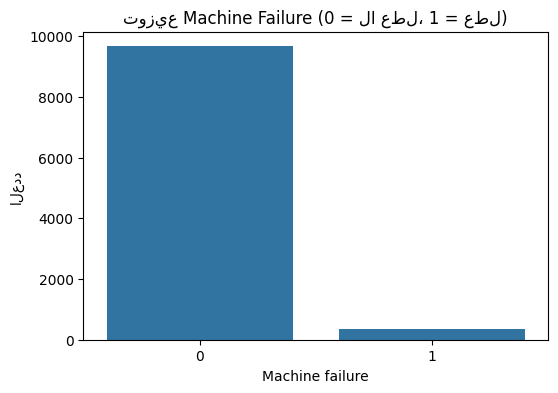

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم توزيع Machine Failure
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df)
plt.title('توزيع Machine Failure (0 = لا عطل، 1 = عطل)')
plt.xlabel('Machine failure')
plt.ylabel('العدد')
plt.show()

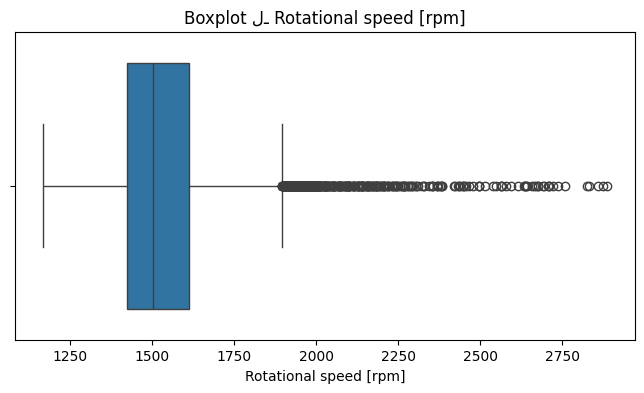

In [11]:
# Boxplot لـ Rotational speed
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Rotational speed [rpm]'])
plt.title('Boxplot لـ Rotational speed [rpm]')
plt.show()

In [12]:
# 1. فحص الصفوف المكررة
print("عدد الصفوف المكررة:", df.duplicated().sum())

# 2. فحص القيم الفريدة في الأعمدة النصية
print("\nالقيم الفريدة في Product ID:", df['Product ID'].nunique())
print("القيم الفريدة في Type:", df['Type'].unique())

عدد الصفوف المكررة: 0

القيم الفريدة في Product ID: 10000
القيم الفريدة في Type: ['M' 'L' 'H']


In [13]:
# حذف الأعمدة غير المفيدة والتي تسبب Data Leakage
columns_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df_clean = df.drop(columns=columns_to_drop)

print("الأعمدة المتبقية بعد الحذف:")
print(df_clean.columns.tolist())
print(f"\nعدد الأعمدة الآن: {df_clean.shape[1]}")
print(f"عدد الصفوف: {df_clean.shape[0]}")

# عرض أول 5 صفوف من البيانات النظيفة
print("\nأول 5 صفوف من البيانات بعد التنظيف:")
display(df_clean.head())

الأعمدة المتبقية بعد الحذف:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

عدد الأعمدة الآن: 7
عدد الصفوف: 10000

أول 5 صفوف من البيانات بعد التنظيف:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


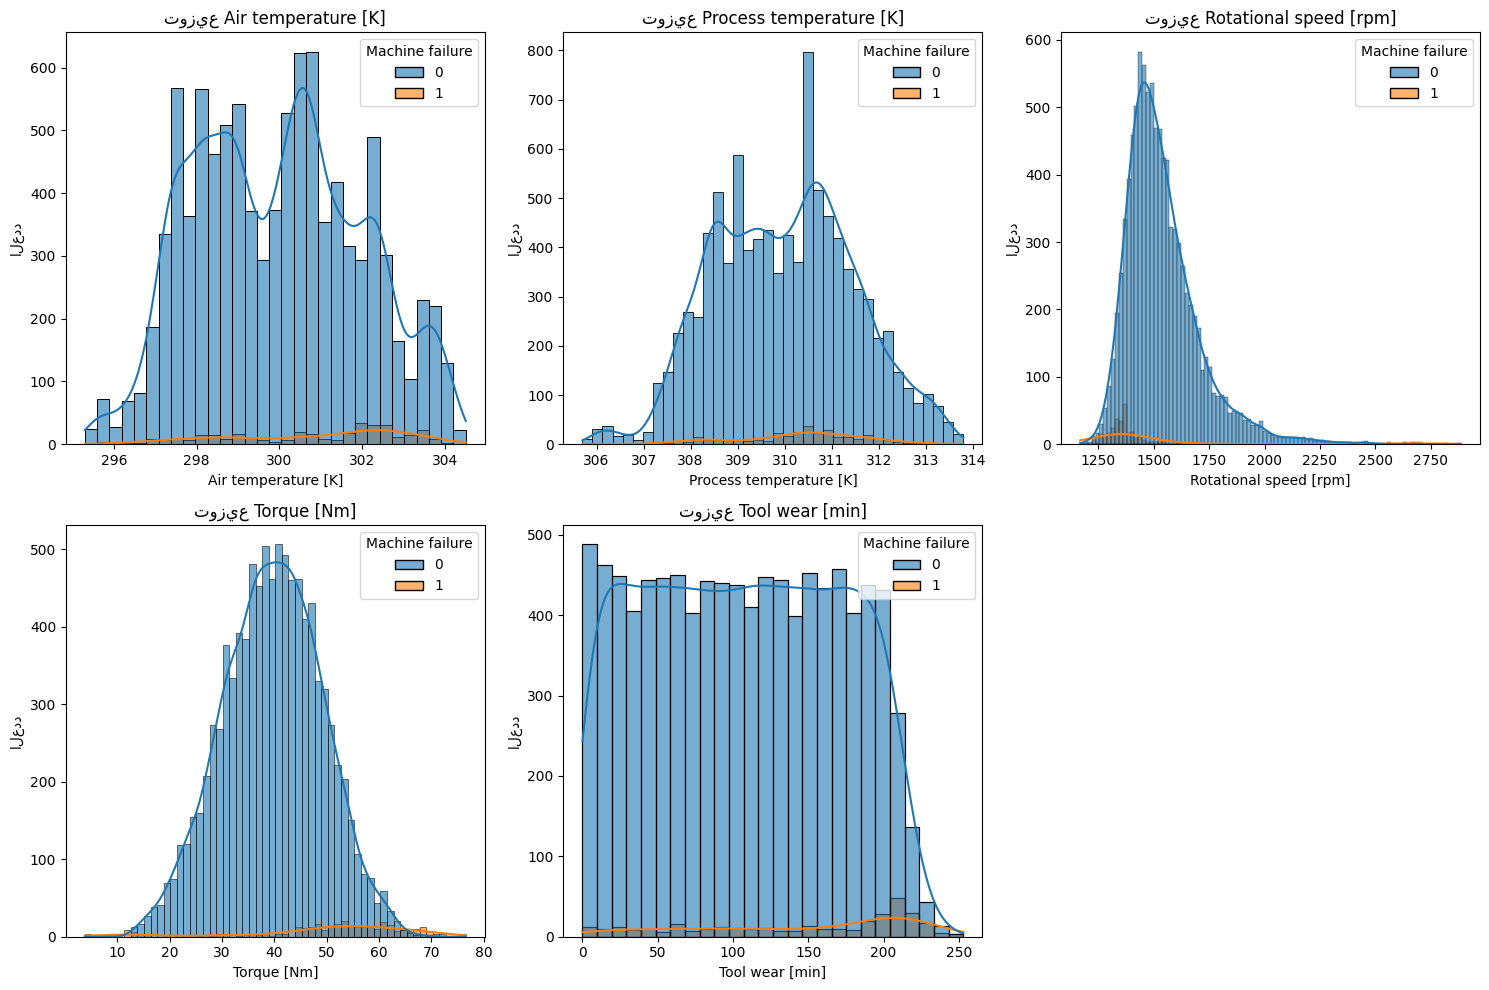

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحديد الأعمدة العددية (باستثناء Type و Machine failure)
numerical_features = ['Air temperature [K]', 'Process temperature [K]',
                      'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# رسم توزيع كل Feature مع تمييز الـTarget
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # رسم Histogram مع KDE
    sns.histplot(data=df_clean, x=feature, hue='Machine failure',
                 kde=True, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'توزيع {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('العدد')

# إخفاء المحور الفارغ السادس
axes[5].axis('off')

plt.tight_layout()
plt.show()

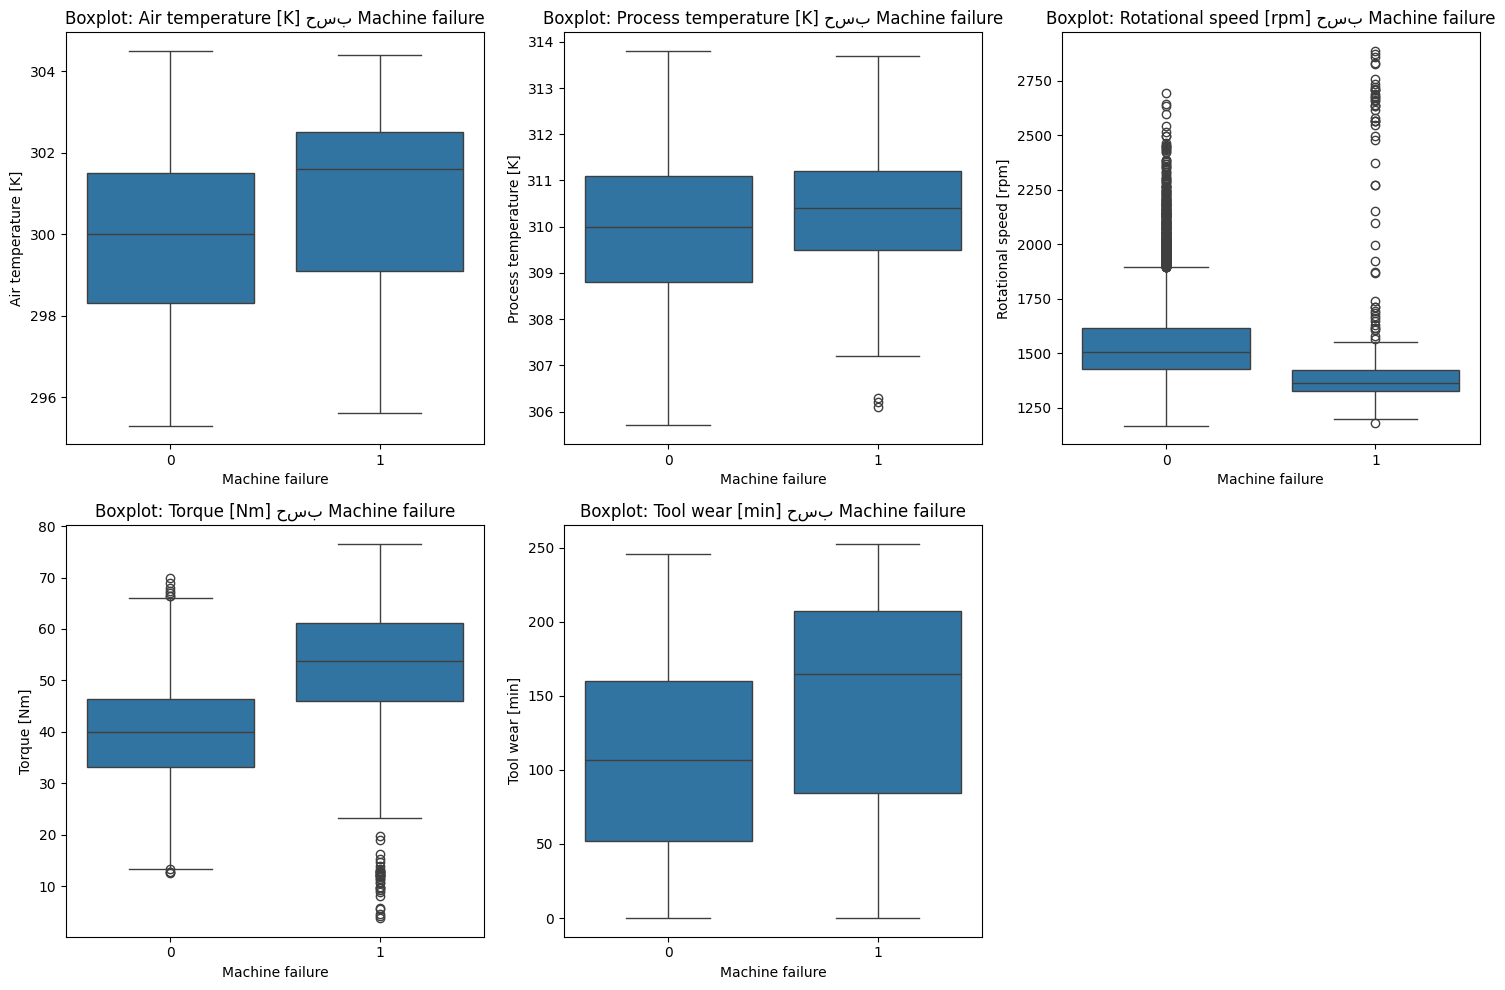

In [15]:
# Boxplots لكل Feature مقارنة بين 0 و 1
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df_clean, x='Machine failure', y=feature, ax=axes[i])
    axes[i].set_title(f'Boxplot: {feature} حسب Machine failure')
    axes[i].set_xlabel('Machine failure')
    axes[i].set_ylabel(feature)

axes[5].axis('off')
plt.tight_layout()
plt.show()

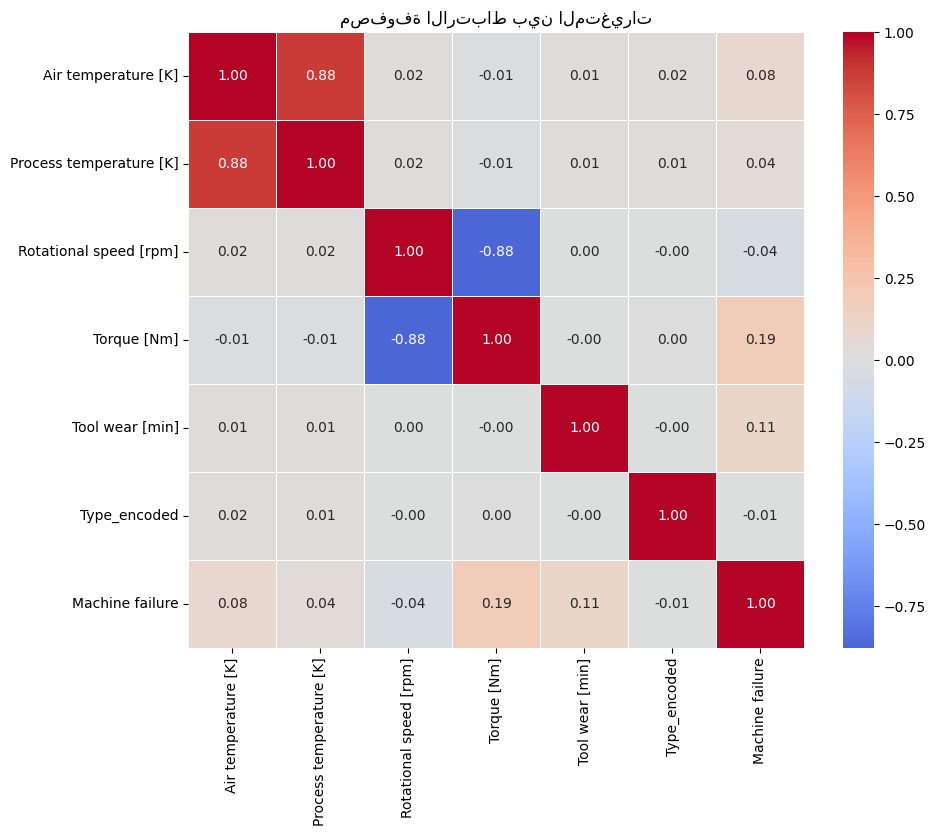

In [16]:
# حساب مصفوفة الارتباط (لنحول Type إلى أرقام مؤقتًا)
from sklearn.preprocessing import LabelEncoder

# نسخة مؤقتة للتحليل فقط
df_corr = df_clean.copy()
le = LabelEncoder()
df_corr['Type_encoded'] = le.fit_transform(df_corr['Type'])

# اختيار الأعمدة الرقمية للارتباط
corr_columns = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'Type_encoded', 'Machine failure']

# حساب مصفوفة الارتباط
plt.figure(figsize=(10, 8))
correlation_matrix = df_corr[corr_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('مصفوفة الارتباط بين المتغيرات')
plt.show()

In [17]:
# حذف Process temperature لتجنب Multi-collinearity
df_final = df_clean.drop(columns=['Process temperature [K]'])

print("الأعمدة المتبقية:")
print(df_final.columns.tolist())
print(f"\nعدد الأعمدة الآن: {df_final.shape[1]}")

الأعمدة المتبقية:
['Type', 'Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

عدد الأعمدة الآن: 6


In [18]:
# One-Hot Encoding لعمود Type
df_encoded = pd.get_dummies(df_final, columns=['Type'], drop_first=False)

print("الأعمدة بعد One-Hot Encoding:")
print(df_encoded.columns.tolist())
print(f"\nعدد الأعمدة الآن: {df_encoded.shape[1]}")

# عرض أول 5 صفوف
print("\nأول 5 صفوف بعد التشفير:")
display(df_encoded.head())

الأعمدة بعد One-Hot Encoding:
['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Type_H', 'Type_L', 'Type_M']

عدد الأعمدة الآن: 8

أول 5 صفوف بعد التشفير:


,Air temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_H,Type_L,Type_M
0,298.1,1551,42.8,0,0,False,False,True
1,298.2,1408,46.3,3,0,False,True,False
2,298.1,1498,49.4,5,0,False,True,False
3,298.2,1433,39.5,7,0,False,True,False
4,298.2,1408,40.0,9,0,False,True,False
